In [1]:
#Importacion de librerias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [27]:
#Importacion de archivo csv
cpi_data = pd.read_csv('Consumer_Price_Index.csv', encoding="cp1252", header = 1)
cpi_data.head()

,Region/Country/Area,Unnamed: 1,Year,Series,Value,Footnotes,Source
0,4,Afghanistan,2005,Consumer price index: General,71.6,NaN,"United Nations Statistics Division (UNSD), New..."
1,4,Afghanistan,2010,Consumer price index: General,100.0,NaN,"United Nations Statistics Division (UNSD), New..."
2,4,Afghanistan,2015,Consumer price index: General,132.9,NaN,"United Nations Statistics Division (UNSD), New..."
3,4,Afghanistan,2021,Consumer price index: General,166.4,NaN,"United Nations Statistics Division (UNSD), New..."
4,4,Afghanistan,2023,Consumer price index: General,180.4,NaN,"United Nations Statistics Division (UNSD), New..."


In [28]:
#Renombre de columnas
cpi_data = cpi_data.rename(columns={"Region/Country/Area": "CountryCode","Unnamed: 1": "CountryName"})
cpi_data.head()

,CountryCode,CountryName,Year,Series,Value,Footnotes,Source
0,4,Afghanistan,2005,Consumer price index: General,71.6,NaN,"United Nations Statistics Division (UNSD), New..."
1,4,Afghanistan,2010,Consumer price index: General,100.0,NaN,"United Nations Statistics Division (UNSD), New..."
2,4,Afghanistan,2015,Consumer price index: General,132.9,NaN,"United Nations Statistics Division (UNSD), New..."
3,4,Afghanistan,2021,Consumer price index: General,166.4,NaN,"United Nations Statistics Division (UNSD), New..."
4,4,Afghanistan,2023,Consumer price index: General,180.4,NaN,"United Nations Statistics Division (UNSD), New..."


In [29]:
#Analisis exploratorio
cpi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2045 entries, 0 to 2044
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CountryCode  2045 non-null   int64 
 1   CountryName  2045 non-null   object
 2   Year         2045 non-null   int64 
 3   Series       2045 non-null   object
 4   Value        2045 non-null   object
 5   Footnotes    1461 non-null   object
 6   Source       2045 non-null   object
dtypes: int64(2), object(5)
memory usage: 112.0+ KB


In [30]:
#Se convirtieron las siguientes variables a categorias
cpi_data["Series"] = cpi_data["Series"].astype("category")
cpi_data["CountryName"] = cpi_data["CountryName"].astype("category")
#La variable Value se convirtio de object a integer
cpi_data["Value"] = pd.to_numeric(cpi_data["Value"], errors="coerce")

In [31]:
cpi_data.info()
#La variable Series representa tipos de indicador económico y, por lo tanto, corresponde a una variable categórica nominal. Se convirtió al tipo 
#category para optimizar el uso de memoria y facilitar operaciones de agrupamiento y filtrado durante el análisis exploratorio.
#La variable Year representa periodos anuales discretos y no timestamps completos, por lo que se eligio mantenerla  como entero(int), ya que
#convertirla a datetime no aporta analíticamente en este caso e incluso podría introducir complejidad innecesaria.
#El dataset de Naciones Unidas se encuentra en formato tidy (Wickham, 2014), donde cada fila representa una observación (país–año–indicador).
#Dado que el objetivo es construir una historia visual sobre tendencias temporales, no fue necesario realizar un pivot estructural, ya que el formato 
#tidy facilita directamente la visualización de series temporales mediante filtrado por indicador.
#El reshape a formato wide sería pertinente en análisis multivariado, pero no es requisito para el analisis exploratorio planteado.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2045 entries, 0 to 2044
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   CountryCode  2045 non-null   int64   
 1   CountryName  2045 non-null   category
 2   Year         2045 non-null   int64   
 3   Series       2045 non-null   category
 4   Value        2020 non-null   float64 
 5   Footnotes    1461 non-null   object  
 6   Source       2045 non-null   object  
dtypes: category(2), float64(1), int64(2), object(2)
memory usage: 95.8+ KB


In [32]:
#Analisis de que indicadores estan disponibles
#Basicamente, en el set de datos existen dos indicadores economicos: El indice de precios generales al consumidor y el indice de precios al consumidor
#en alimentos. Estos indicadores permiten analizar tanto la inflación general como el comportamiento específico de los precios de alimentos, los cuales
#suelen presentar mayor volatilidad y relevancia para el ambiente o bienestar económico de los paises. De hecho, en las noticias economicas, suele
#hacerse la distincion entre inflacion general versus inflacion subyacente o estructural(core inflation) siendo esta ultima la que excluye precios de 
#alimentos y energia por su volatilidad (guerras, shocks de oferta); el objetivo es que los economistas puedan medir la tendencia de fondo en los 
#precios
cpi_data['Series'].value_counts()
#Aqui faltaria el componente energetico para poder analizar la inflacion subyacente. El set de datos solo tiene el CPI general como medida de la 
#inflacion total y el CPI en alimentos como medida de la inflacion en alimentos.

Series
Consumer price index: General    1227
Consumer price index: Food        818
Name: count, dtype: int64

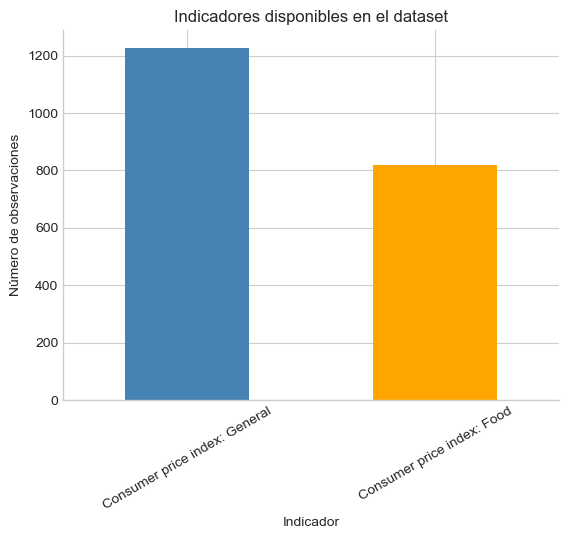

In [33]:
#Grafica del numero de datos u observaciones por indicador
cpi_data["Series"].value_counts().plot(kind="bar",color=["steelblue","orange"])
plt.title("Indicadores disponibles en el dataset")
plt.ylabel("Número de observaciones")
plt.xlabel("Indicador")
plt.xticks(rotation=30)
plt.gca().spines[['top','right']].set_visible(False)
plt.show()
#Principios  de visualizacion aplicados
#Tufte: gráfico simple
#Gestalt:color para separar categorías, agrupación clara
#Puede observarse que no existe la misma disponibilidad de datos para cada indice

In [34]:
#Filtro de un indicador
cpi_general = cpi_data[cpi_data["Series"] == "Consumer price index: General"]
#Agrupacion del indicador por ano
cpi_year = cpi_general.groupby("Year")["Value"].mean()

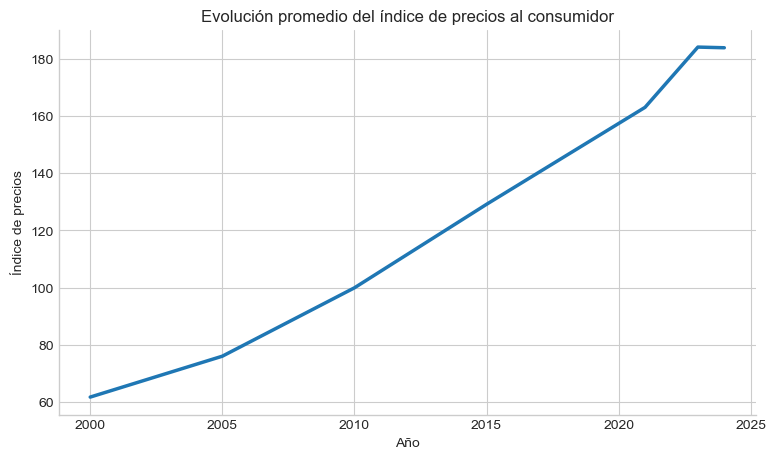

In [35]:
#Evolucion global en el tiempo del indice de precios al consumidor (Inflacion general)
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(9,5))
plt.plot(cpi_year.index, cpi_year.values, linewidth=2.5)
plt.title("Evolución promedio del índice de precios al consumidor")
plt.xlabel("Año")
plt.ylabel("Índice de precios")
plt.gca().spines[['top','right']].set_visible(False)
plt.show()
#El gráfico muestra la evolución promedio del índice de precios al consumidor a lo largo del tiempo. La visualización sigue el principio de Prägnanz 
#al presentar una estructura simple con una única línea que permite identificar claramente la tendencia. Asimismo, se aplica la correspondencia 
#isomórfica al representar el tiempo en el eje horizontal y el índice de precios en el eje vertical. Finalmente, se sigue el enfoque de Tufte al 
#eliminar elementos visuales innecesarios.

In [36]:
#cpi_data[cpi_data["CountryName"] == "Iran (Islamic Republic of)"]

In [37]:
#Exploracion de que paises hay
cpi_data["CountryName"].unique()

['Afghanistan', 'Åland Islands', 'Albania', 'Algeria', 'Andorra', ..., 'Venezuela (Boliv. Rep. of)', 'Viet Nam', 'Yemen', 'Zambia', 'Zimbabwe']
Length: 202
Categories (202, object): ['Afghanistan', 'Albania', 'Algeria', 'Andorra', ..., 'Yemen', 'Zambia', 'Zimbabwe', 'Åland Islands']

In [38]:
#cpi_data[cpi_data["CountryName"].str.contains("Korea", case=False)]

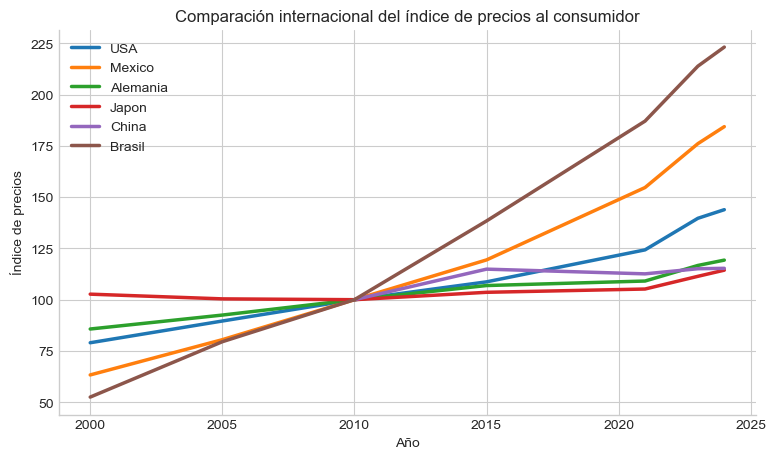

In [39]:
#Para la comparación internacional se seleccionó un conjunto de economías grandes o medianas con instituciones monetarias relativamente estables y 
#disponibilidad consistente de datos(Salvo China). Este grupo incluye tanto economías desarrolladas como emergentes, permitiendo observar patrones 
#inflacionarios en distintos contextos económicos. México se incluye como caso de interés específico dentro del análisis comparativo.
#3 economias desarrolladas: Estados Unidos, Alemania, y Japon y 3 economias emergentes : China,Mexico,Brasil
#Este subconjunto de países son representativos de diferentes regiones y niveles de desarrollo económico. No se seleccionaron mas
#ya que La inclusión de demasiadas series en una sola gráfica y el cambio de escala por paises outliers dificulta
#la comparación directa de tendencias inflacionarias.(Dejaria de ser simple)
countries = ["United States of America","Mexico","Germany","Japan","China","Brazil"]
#Filtrado de los paises
cpi_countries = cpi_general[cpi_general["CountryName"].isin(countries)]
#Diccionario de etiquetas
label_map = {"United States of America": "USA","Germany": "Alemania","Japan":"Japon","Brazil":"Brasil"}
#Grafico de comparacion entre paises
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(9,5))
for country in countries:
    temp = cpi_countries[cpi_countries["CountryName"] == country].sort_values("Year")
    plt.plot(temp["Year"], temp["Value"], linewidth=2.5, label=label_map.get(country,country))
plt.title("Comparación internacional del índice de precios al consumidor")
plt.xlabel("Año")
plt.ylabel("Índice de precios")
plt.legend()
plt.gca().spines[['top','right']].set_visible(False)
plt.show()
#Principios de visualizacion aplicados
#Se aplican principios de Gestalt como el confinamiento, al agrupar las series dentro del mismo espacio visual, y la correspondencia isomórfica al 
#representar el tiempo en el eje horizontal y el índice de precios en el vertical. Además, siguiendo las recomendaciones de Tufte, se eliminan 
#elementos visuales innecesarios para facilitar la comparación entre las distintas economías.

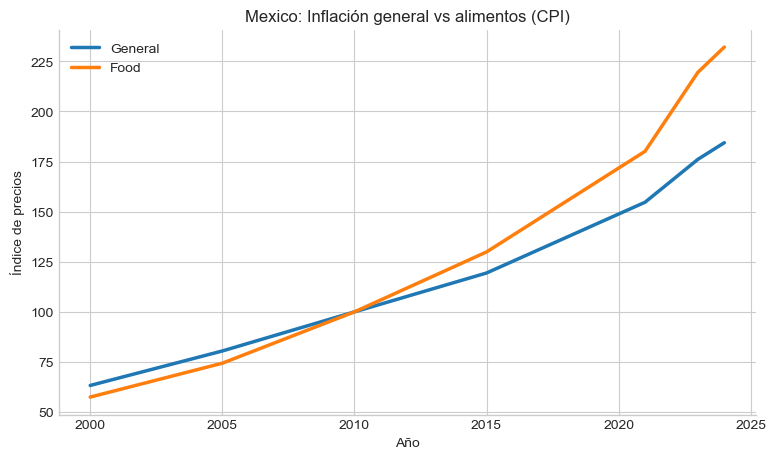

In [40]:
#La inflacion en alimentos se mueve de la misma forma que la inflacion general?

country = "Mexico"
df_mx = cpi_data[cpi_data["CountryName"] == country].copy()

series_to_plot = ["Consumer price index: General", "Consumer price index: Food"]
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(9,5))
for s in series_to_plot:
    temp = df_mx[df_mx["Series"] == s].sort_values("Year")
    plt.plot(temp["Year"], temp["Value"], linewidth=2.5, label=s.replace("Consumer price index: ", ""))

plt.title(f"{country}: Inflación general vs alimentos (CPI)")
plt.xlabel("Año")
plt.ylabel("Índice de precios")
plt.legend()
plt.gca().spines[['top','right']].set_visible(False)
plt.show()
#Este gráfico compara la evolución de la inflación general y la inflación en alimentos en México(El objetivo ahora es comparar dos variables
#dentro de un mismo pais) . Se aplican principios de Gestalt como el confinamiento al mostrar ambas series en el mismo espacio visual, facilitando su
#comparación. Además, el punto de  divergencia entre ambas líneas crea un punto focal que permite identificar que los precios de los alimentos han 
#aumentado más rápidamente que el índice general en los últimos años.

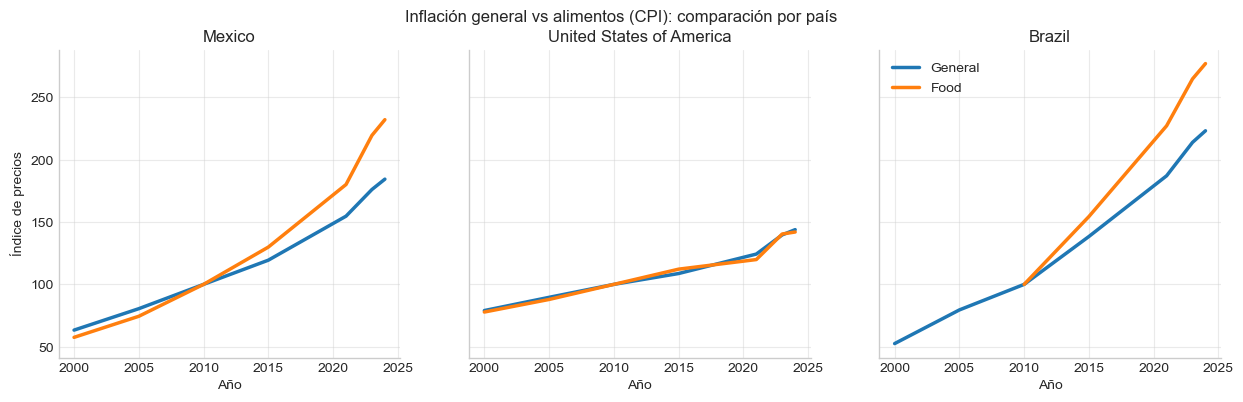

In [41]:
#Inflacion general contra inflacion de alimentos en distintos paises
#La grafica muestra que Mexico y Brasil presentan un mayor crecimiento en la inflacion de los alimentos comparado a la inflacion general.Esto es un 
#patron observado en varias economias emergentes, donde los precios de los alimentos son aun mas volatiles por diversos factores como tipo de cambio,
#escasez energetica, crisis climaticas. En contraste, para los Estados Unidos ambas series tienen trayectorias muy similares sugiriendo una mayor
#estabilidad en la cadena de suministro y menor peso de los alimentos en la inflacion general.
#Lo anterior implica que en economias emergentes los consumidores de ingresos bajos sufren mas porque gastarian en mayor proporcion en comida
#(Un impacto social mayor)

countries_compare = ["Mexico", "United States of America", "Brazil"]
series_to_plot = ["Consumer price index: General", "Consumer price index: Food"]
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,4), sharey=True)
for ax, country in zip(axes, countries_compare):
    df_c = cpi_data[cpi_data["CountryName"] == country].copy()
    for s in series_to_plot:
        temp = df_c[df_c["Series"] == s].sort_values("Year")
        ax.plot(temp["Year"], temp["Value"], linewidth=2.5, label=s.replace("Consumer price index: ", ""))
    ax.set_title(country)
    ax.set_xlabel("Año")
    ax.grid(True,alpha = 0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
axes[0].set_ylabel("Índice de precios")
axes[-1].legend()
plt.suptitle("Inflación general vs alimentos (CPI): comparación por país")
plt.show()
#Se hace uso de subgráficos para facilitar la comparacion de  la evolución de la inflación general y de alimentos en distintos países. Se aplican 
#principios de Gestalt como el confinamiento y la simetría, ya que cada país se presenta en un panel con la misma estructura visual. Esto facilita 
#la comparación entre economías. La divergencia entre las líneas dentro de cada panel permite identificar (Al igual que en el grafico anterior)
#diferencias en el comportamiento de los precios, mostrando que en algunos países los alimentos presentan un crecimiento mayor que la inflación general.

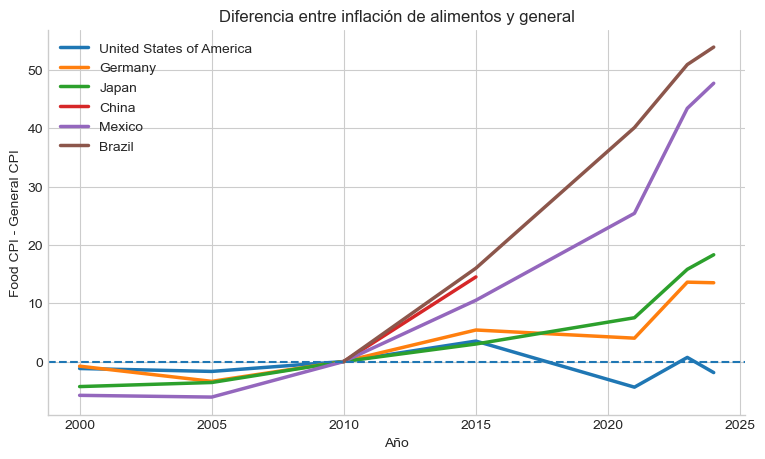

In [42]:
#Diferencia entre inflacion alimentaria y general
countries = ["United States of America","Germany","Japan","China","Mexico","Brazil"]
df = cpi_data[cpi_data["CountryName"].isin(countries)]

#pivot
pivot= df.pivot_table(index = ['CountryName','Year'], columns = 'Series', values = 'Value',observed= False).reset_index()

#Calculo de diferencia
pivot["Food_vs_General"] = (pivot["Consumer price index: Food"] -pivot["Consumer price index: General"])
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(9,5))
for country in countries:
    temp = pivot[pivot["CountryName"] == country]
    plt.plot(temp["Year"], temp["Food_vs_General"], linewidth=2.5, label=country)

plt.axhline(0, linestyle="--")
plt.title("Diferencia entre inflación de alimentos y general")
plt.xlabel("Año")
plt.ylabel("Food CPI - General CPI")
plt.legend()
plt.gca().spines[['top','right']].set_visible(False)
plt.show()

#El análisis muestra que la inflación de alimentos tiende a crecer más rápidamente que la inflación general en economías emergentes como México y 
#Brasil. En contraste, en economías desarrolladas como Estados Unidos ambas series presentan trayectorias similares, lo que sugiere una mayor 
#estabilidad en los precios relativos de los alimentos. La diferencia entre ambas series permite visualizar claramente estas dinámicas y resalta la 
#mayor sensibilidad de los precios alimentarios a shocks económicos.
#Principios aplicados
#Punto focal
#La línea horizontal en cero permite identificar inmediatamente cuándo los alimentos crecen más rápido que la inflación general.
#Correspondencia isomórfica
#Las desviaciones respecto a cero representan visualmente la magnitud de la diferencia.
#Prägnanz
#La transformación de los datos en una sola métrica simplifica la interpretación.

In [43]:
#El análisis muestra una tendencia general de aumento en el índice de precios al consumidor a lo largo del tiempo. Sin embargo, la dinámica inflacionaria 
#varía entre países por diversos y muy variados factores. En economías emergentes como México y Brasil, los precios de los alimentos crecen más rápido 
#que la inflación general, mientras que por ejemplo en Estados Unidos ambas series evolucionan de manera similar y en Europa hay un impacto moderado.
#Esto sugiere que la inflación alimentaria puede representar una presión adicional con un impacto mucho mayor para las economías emergentes.